# Physics-Informed Neural Networks (PINNs)

In this notebook, we build our first Physics-Informed Neural Network (PINN) using PyTorch.

Instead of training the neural network on a large dataset, we teach it to satisfy a differential equation.

We will solve the following Ordinary Differential Equation (ODE):

dy/dx = y

with the boundary condition

y(0) = 1

The analytical solution is

y = e^x

Our objective is to see whether a neural network can discover this solution using only the governing physics.

In [1]:
# PyTorch
import torch
import torch.nn as nn

# Numerical computations
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Set random seed

Nerual networks initialize their parameters randomly.
So we set the random seed, so that every run start from the same initial condition.

In [2]:
torch.manual_seed(42)
np.random.seed(42)

print("Random seed set successfully")

Random seed set successfully


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using Device : {device}")
if device.type == "cuda":
    print(f"GPU name : {torch.cuda.get_device_name(0)}")

Using Device : cuda
GPU name : NVIDIA GeForce RTX 2050


# Build the Physics-Informed Neural Network

The objective of the neural network is to approximate the unknown solution
function y(x).

The network receives the input coordinate x and predicts the corresponding
value y(x).

During training, the predicted function will be constrained to satisfy:

- The governing differential equation
- The boundary condition

For this example, we use a simple fully connected feedforward neural network.

In [4]:
class PINN(nn.Module):

    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(1,32),
            nn.Tanh(),

            nn.Linear(32,32),
            nn.Tanh(),

            nn.Linear(32,32),
            nn.Tanh(),

            nn.Linear(32,1)
        )
    def forward(self,x):
        return self.network(x)

In [5]:
model = PINN().to(device)
print(model)

PINN(
  (network): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=32, bias=True)
    (5): Tanh()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [6]:
x_min =0.0
x_max =1.0

n_points =100

x_train =torch.linspace(x_min,x_max,n_points).view(-1,1)

x_train = x_train.to(device)

print(x_train.shape)

torch.Size([100, 1])


In [7]:
x_example = torch.tensor([[0.5]], dtype=torch.float32).to(device)
#forward pass
with torch.no_grad():
    y_example = model(x_example)
print("Input :",x_example.item())
print("Prediction :",y_example.item())

Input : 0.5
Prediction : -0.04991725832223892


# Ploting the points

In [8]:
# Enable gradient tracking on the input
x_train.requires_grad_(True)

# Forward pass (NO torch.no_grad() here!)
y_pred = model(x_train)

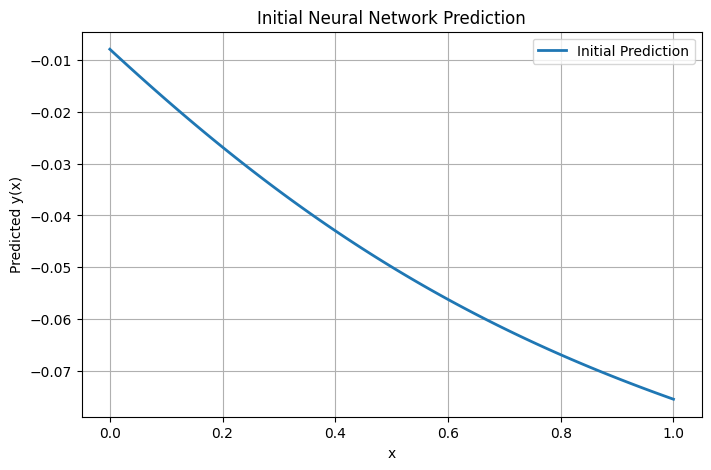

In [9]:
plt.figure(figsize=(8,5))

plt.plot(
    x_train.detach().cpu().numpy(),
    y_pred.detach().cpu().numpy(),
    linewidth=2,
    label="Initial Prediction"
)
plt.xlabel("x")
plt.ylabel("Predicted y(x)")
plt.title("Initial Neural Network Prediction")
plt.grid(True)
plt.legend()

plt.show()

In [10]:
x_train.requires_grad_(True)

tensor([[0.0000],
        [0.0101],
        [0.0202],
        [0.0303],
        [0.0404],
        [0.0505],
        [0.0606],
        [0.0707],
        [0.0808],
        [0.0909],
        [0.1010],
        [0.1111],
        [0.1212],
        [0.1313],
        [0.1414],
        [0.1515],
        [0.1616],
        [0.1717],
        [0.1818],
        [0.1919],
        [0.2020],
        [0.2121],
        [0.2222],
        [0.2323],
        [0.2424],
        [0.2525],
        [0.2626],
        [0.2727],
        [0.2828],
        [0.2929],
        [0.3030],
        [0.3131],
        [0.3232],
        [0.3333],
        [0.3434],
        [0.3535],
        [0.3636],
        [0.3737],
        [0.3838],
        [0.3939],
        [0.4040],
        [0.4141],
        [0.4242],
        [0.4343],
        [0.4444],
        [0.4545],
        [0.4646],
        [0.4747],
        [0.4848],
        [0.4949],
        [0.5051],
        [0.5152],
        [0.5253],
        [0.5354],
        [0.5455],
        [0

In [11]:
dy_dx = torch.autograd.grad(
    outputs=y_pred,
    inputs=x_train,
    grad_outputs=torch.ones_like(y_pred),
    create_graph=True
)[0]

C:\Users\ASUS\anaconda3\envs\neuro\Lib\site-packages\torch\autograd\graph.py:825: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\cuda\CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


**Automati Diffrentiation**

 dy/dx = y

In [12]:
print(dy_dx.shape)

torch.Size([100, 1])


In [13]:
print(dy_dx[:5])

tensor([[-0.1004],
        [-0.0999],
        [-0.0993],
        [-0.0988],
        [-0.0982]], device='cuda:0', grad_fn=<SliceBackward0>)


In [14]:
residual = dy_dx - y_pred

In [15]:
print(residual.shape)

torch.Size([100, 1])


In [16]:
print(residual[:5])

tensor([[-0.0925],
        [-0.0909],
        [-0.0894],
        [-0.0878],
        [-0.0862]], device='cuda:0', grad_fn=<SliceBackward0>)


In [17]:
physics_loss = torch.mean(residual**2)
print(physics_loss)

tensor(0.0019, device='cuda:0', grad_fn=<MeanBackward0>)


In [18]:
# Boundary point
x_bc = torch.tensor([[0.0]], device=device)
y_bc = torch.tensor([[1.0]], device=device)

y_bc_pred = model(x_bc)

boundary_loss = torch.mean((y_bc_pred - y_bc)** 2)

print(boundary_loss)

tensor(1.0160, device='cuda:0', grad_fn=<MeanBackward0>)


In [19]:
total_loss = physics_loss + boundary_loss
print(total_loss)

tensor(1.0179, device='cuda:0', grad_fn=<AddBackward0>)


# Optimizer

The optimizer updates the neural network weights to minimize the total loss.
We use the Adam optimizer because it converges quickly and is commonly used
for training Physics-Informed Neural Networks.

In [20]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [21]:
epochs = 5000

loss_history = []

for epoch in range(epochs):

    optimizer.zero_grad()

    # Enable gradients
    x_train.requires_grad_(True)

    # Forward pass
    y_pred = model(x_train)

    # Compute derivative
    dy_dx = torch.autograd.grad(
        outputs=y_pred,
        inputs=x_train,
        grad_outputs=torch.ones_like(y_pred),
        create_graph=True
    )[0]

    # Physics loss
    residual = dy_dx - y_pred
    physics_loss = torch.mean(residual ** 2)

    y_bc_pred = model(x_bc)
    boundary_loss = torch.mean((y_bc_pred - y_bc) ** 2)

    # Total loss
    total_loss = physics_loss + boundary_loss

    # Backpropagation
    total_loss.backward()

    # Update weights
    optimizer.step()

    loss_history.append(total_loss.item())

    if epoch % 500 == 0:
        print(
            f"Epoch {epoch:5d} | "
            f"Physics: {physics_loss.item():.6f} | "
            f"Boundary: {boundary_loss.item():.6f} | "
            f"Total: {total_loss.item():.6f}"
        )

Epoch     0 | Physics: 0.001913 | Boundary: 1.015952 | Total: 1.017865
Epoch   500 | Physics: 0.000024 | Boundary: 0.000000 | Total: 0.000024
Epoch  1000 | Physics: 0.000010 | Boundary: 0.000000 | Total: 0.000010
Epoch  1500 | Physics: 0.000007 | Boundary: 0.000000 | Total: 0.000007
Epoch  2000 | Physics: 0.000006 | Boundary: 0.000000 | Total: 0.000006
Epoch  2500 | Physics: 0.000005 | Boundary: 0.000000 | Total: 0.000005
Epoch  3000 | Physics: 0.000005 | Boundary: 0.000000 | Total: 0.000005
Epoch  3500 | Physics: 0.000004 | Boundary: 0.000000 | Total: 0.000004
Epoch  4000 | Physics: 0.000009 | Boundary: 0.000002 | Total: 0.000011
Epoch  4500 | Physics: 0.000004 | Boundary: 0.000000 | Total: 0.000004


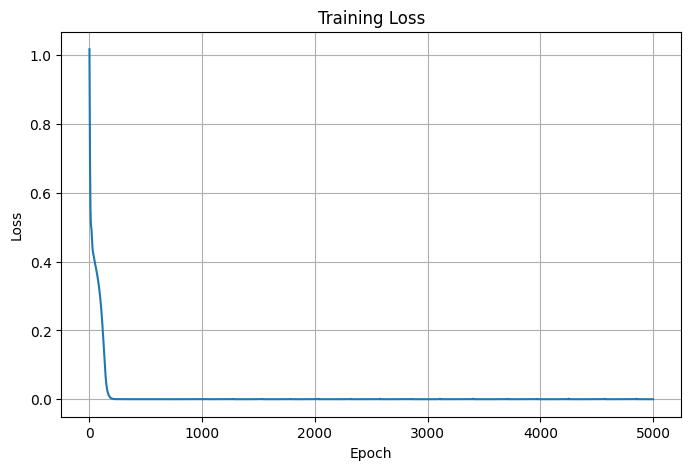

In [22]:
plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()

In [23]:
with torch.no_grad():
    y_final= model(x_train)
y_exact = torch.exp(x_train)

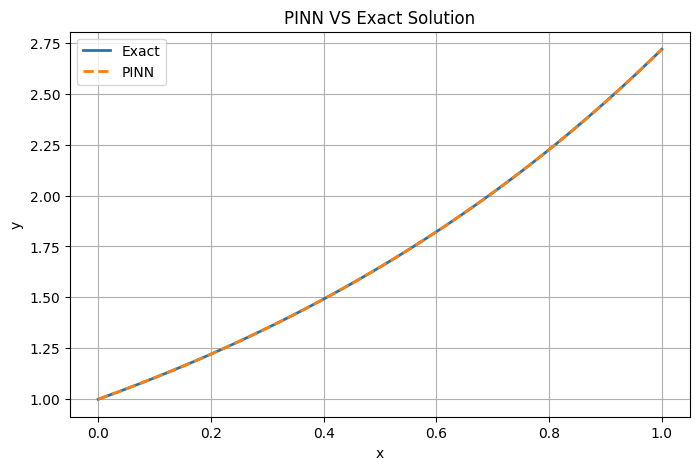

In [24]:
plt.figure(figsize=(8,5))

plt.plot(
    x_train.detach().cpu().numpy(),
    y_exact.detach().cpu().numpy(),
    label="Exact",
    linewidth=2
)

plt.plot(
    x_train.detach().cpu().numpy(),
    y_final.detach().cpu().numpy(),
    "--",
    label="PINN",
    linewidth=2
)
plt.xlabel("x")
plt.ylabel("y")
plt.title("PINN VS Exact Solution")
plt.legend()
plt.grid(True)
plt.show()

In [25]:
print(f"Physics Loss : {physics_loss.item():.8f}")
print(f"Boundary Loss: {boundary_loss.item():.8f}")
print(f"Total Loss   : {total_loss.item():.8f}")

Physics Loss : 0.00000331
Boundary Loss: 0.00000000
Total Loss   : 0.00000331
